식별자

UDI — 고유 데이터 식별자 (1 ~ 10,000), 학습에서 제외
Product ID — 제품 일련번호 (예: L47181), 학습에서 제외

범주형

Type — 제품 품질 등급 (L 50% / M 30% / H 20%), 인코딩 필요

수치형 센서값

Air temperature [K] — 공기 온도 (~298 ~ 304 K)
Process temperature [K] — 공정 온도, Air보다 약 10K 높음 (~308 ~ 314 K)
Rotational speed [rpm] — 회전 속도 (~1168 ~ 2886 rpm)
Torque [Nm] — 토크, rpm과 음의 상관관계 (~3.8 ~ 76.6 Nm)
Tool wear [min] — 공구 누적 사용 시간 (0 ~ 253 min)

타겟

Machine failure — 고장 여부 (0=정상 / 1=고장, 약 3.4%)
TWF — Tool Wear Failure, 마모 200~240min 구간에서 랜덤 발생
HDF — Heat Dissipation Failure, 온도 차 < 8.6K & rpm < 1380  공정온도와 공기온도의 차이
PWF — Power Failure, 토크 × rpm 범위 초과 시
OSF — Overstrain Failure, 토크 × 마모 임계값 초과 시
RNF — Random Failure, 0.1% 확률로 랜덤 발생

추천 파생변수 (직접 생성)

Temp_diff = Process temp − Air temp → HDF 탐지 핵심
Power = Torque × rpm × (2π/60) → PWF 탐지 핵심
Torque_Wear = Torque × Tool wear → OSF 탐지 핵심

In [9]:
#데이터 로드 및 간단한 셀 확인


import pandas as pd
import numpy as np

df = pd.read_csv('ai4i2020.csv')
df.columns = df.columns.str.strip()

print(f"shape: {df.shape}")
print(f"결측치: {df.isnull().sum().sum()}")
print(f"중복행: {df.duplicated().sum()}")
df.head()

shape: (10000, 14)
결측치: 0
중복행: 0


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [10]:
# 수치형 변수 기초 통계
num_cols = ['Air temperature [K]', 'Process temperature [K]',
            'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']

df[num_cols].describe().round(2)


,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min]
count,10000.0,10000.00,10000.00,10000.00,10000.00
mean,300.0,310.01,1538.78,39.99,107.95
std,2.0,1.48,179.28,9.97,63.65
min,295.3,305.70,1168.00,3.80,0.00
25%,298.3,308.80,1423.00,33.20,53.00
50%,300.1,310.10,1503.00,40.10,108.00
75%,301.5,311.10,1612.00,46.80,162.00
max,304.5,313.80,2886.00,76.60,253.00


In [11]:
# 타겟 분포
print("── 고장 비율 ──")
print(df['Machine failure'].value_counts())
print(f"고장률: {df['Machine failure'].mean()*100:.2f}%")
print()

# 고장 유형별 발생 수
print("── 고장 유형별 ──")
failure_types = ['TWF', 'HDF', 'PWF', 'OSF', 'RNF']
print(df[failure_types].sum())

── 고장 비율 ──
Machine failure
0    9661
1     339
Name: count, dtype: int64
고장률: 3.39%

── 고장 유형별 ──
TWF     46
HDF    115
PWF     95
OSF     98
RNF     19
dtype: int64


In [12]:
#파생변수를 만들기 위한 조건보기

df['Temp_diff'] = df['Process temperature [K]'] - df['Air temperature [K]']

print("── Temp_diff 기초 통계 ──")
print(df['Temp_diff'].describe().round(2))
print()

# HDF 고장 조건 검증
print("── HDF 조건 해당 샘플 수 ──")
hdf_condition = (df['Temp_diff'] < 8.6) & (df['Rotational speed [rpm]'] < 1380)
print(f"조건 해당: {hdf_condition.sum()}건")
print(f"실제 HDF 발생: {df['HDF'].sum()}건")
print()

# 고장군 vs 정상군 Temp_diff 비교
print("── Temp_diff 평균 비교 ──")
print(df.groupby('Machine failure')['Temp_diff'].mean().round(3))

── Temp_diff 기초 통계 ──
count    10000.0
mean        10.0
std          1.0
min          7.6
25%          9.3
50%          9.8
75%         11.0
max         12.1
Name: Temp_diff, dtype: float64

── HDF 조건 해당 샘플 수 ──
조건 해당: 115건
실제 HDF 발생: 115건

── Temp_diff 평균 비교 ──
Machine failure
0    10.022
1     9.404
Name: Temp_diff, dtype: float64


# PWF, OSF의 파생변수 만들기

* Power → PWF 조건인 "전력이 범위를 벗어나면 고장" 을 계산하기 위해 만든 것
* Torque_Wear → OSF 조건인 "토크 × 마모가 임계값 초과하면 고장" 을 계산하기 위해 만든 것

* 파생변수조건 해당실제 고장일치율Temp_diff → HDF115건115건100% ✅
* Power → PWF95건95건100% ✅
* Torque_Wear → OSF98건98건100% ✅

### 단순히 변수를 만든 게 아니라 도메인 지식 기반으로 고장 조건을 역공학해서 검증함

In [14]:
df['Power'] = df['Torque [Nm]'] * df['Rotational speed [rpm]'] * (2 * 3.14159 / 60)
df['Torque_Wear'] = df['Torque [Nm]'] * df['Tool wear [min]']

# PWF 조건 검증 (전력 범위: 3500 ~ 9000W 벗어나면 고장)
print("── PWF 조건 검증 ──")
pwf_condition = (df['Power'] < 3500) | (df['Power'] > 9000)
print(f"조건 해당: {pwf_condition.sum()}건")
print(f"실제 PWF 발생: {df['PWF'].sum()}건")
print()

# OSF 조건 검증 (타입별 임계값 다름)
print("── OSF 조건 검증 ──")
osf_condition = (
    ((df['Type'] == 'L') & (df['Torque_Wear'] > 11000)) |
    ((df['Type'] == 'M') & (df['Torque_Wear'] > 12000)) |
    ((df['Type'] == 'H') & (df['Torque_Wear'] > 13000))
)
print(f"조건 해당: {osf_condition.sum()}건")
print(f"실제 OSF 발생: {df['OSF'].sum()}건")
print()

# 파생변수 통계
print("── Power 기초 통계 ──")
print(df['Power'].describe().round(1))
print()
print("── Torque_Wear 기초 통계 ──")
print(df['Torque_Wear'].describe().round(1))

── PWF 조건 검증 ──
조건 해당: 95건
실제 PWF 발생: 95건

── OSF 조건 검증 ──
조건 해당: 98건
실제 OSF 발생: 98건

── Power 기초 통계 ──
count    10000.0
mean      6279.7
std       1067.4
min       1148.4
25%       5561.2
50%       6271.0
75%       7003.0
max      10469.9
Name: Power, dtype: float64

── Torque_Wear 기초 통계 ──
count    10000.0
mean      4314.7
std       2826.6
min          0.0
25%       1963.6
50%       4013.0
75%       6279.0
max      16497.0
Name: Torque_Wear, dtype: float64


In [15]:
# IQR 기반 이상치 탐지
num_cols = ['Air temperature [K]', 'Process temperature [K]',
            'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]',
            'Power', 'Torque_Wear']

print("── IQR 기반 이상치 개수 ──")
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = ((df[col] < Q1 - 1.5 * IQR) | (df[col] > Q3 + 1.5 * IQR)).sum()
    print(f"{col}: {outliers}건 ({outliers/len(df)*100:.2f}%)")

── IQR 기반 이상치 개수 ──
Air temperature [K]: 0건 (0.00%)
Process temperature [K]: 0건 (0.00%)
Rotational speed [rpm]: 418건 (4.18%)
Torque [Nm]: 69건 (0.69%)
Tool wear [min]: 0건 (0.00%)
Power: 60건 (0.60%)
Torque_Wear: 20건 (0.20%)



- [Rotational speed → 418건 (4.18%) ⚠️]

* 가장 많은 이상치
* rpm이 특정 구간에서 급격히 튀는 케이스들이에요
* PWF, HDF 고장과 연관 가능성 높아요

- [Torque → 69건 (0.69%)]
* rpm과 음의 상관관계라서 rpm 이상치와 겹치는 케이스가 있을 거예요

-[ Power → 60건 (0.60%)]
* Power = Torque × rpm이니까 두 개의 이상치가 합쳐진 결과예요
이 중 일부가 PWF 고장(95건)과 겹칠 가능성 높아요

- [Torque_Wear → 20건 (0.20%)]

* OSF 고장(98건)보다 훨씬 적은데, IQR 기준이 엄격해서 그래요
* 임계값 초과 케이스가 IQR 범위 안에 들어오는 경우도 있다는 뜻

In [16]:
# rpm 이상치가 고장과 얼마나 겹치는지 확인
Q1 = df['Rotational speed [rpm]'].quantile(0.25)
Q3 = df['Rotational speed [rpm]'].quantile(0.75)
IQR = Q3 - Q1

rpm_outlier = (df['Rotational speed [rpm]'] < Q1 - 1.5*IQR) | \
              (df['Rotational speed [rpm]'] > Q3 + 1.5*IQR)

print("── rpm 이상치 vs 고장 여부 ──")
print(df[rpm_outlier]['Machine failure'].value_counts())
print(f"이상치 중 고장 비율: {df[rpm_outlier]['Machine failure'].mean()*100:.1f}%")
print(f"전체 고장 비율: {df['Machine failure'].mean()*100:.1f}%")

── rpm 이상치 vs 고장 여부 ──
Machine failure
0    383
1     35
Name: count, dtype: int64
이상치 중 고장 비율: 8.4%
전체 고장 비율: 3.4%


 이상치를 제거하면 안 돼요. 이유는 두 가지예요.
첫째, 이상치 418건 중 고장이 35건 포함되어 있어서 제거하면 희귀한 고장 샘플을 날리는 거예요. 고장 데이터가 전체 339건밖에 없는데 35건(10%)을 버리는 건 손해가 너무 커요.
둘째, 이상치 자체가 고장의 원인이나 신호일 수 있어서 모델이 반드시 학습해야 할 패턴이에요.

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

# 상관관계 분석할 컬럼
corr_cols = ['Air temperature [K]', 'Process temperature [K]',
             'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]',
             'Temp_diff', 'Power', 'Torque_Wear', 'Machine failure']

corr = df[corr_cols].corr().round(3)

# Machine failure와의 상관계수만 먼저 출력

print("── Machine failure와의 상관계수 ──")
print(corr['Machine failure'].drop('Machine failure').sort_values(key=abs, ascending=False))

── Machine failure와의 상관계수 ──
Torque [Nm]                0.191
Torque_Wear                0.190
Power                      0.176
Temp_diff                 -0.112
Tool wear [min]            0.105
Air temperature [K]        0.083
Rotational speed [rpm]    -0.044
Process temperature [K]    0.036
Name: Machine failure, dtype: float64


Rotational speed가 -0.044로 거의 0에 가까움. rpm 단독으로는 고장 예측력이 낮은데, 아까 이상치 분석에서 고장 비율이 2.5배였던 거랑 모순처럼 보임
이건 비선형 관계 때문. 피어슨 상관계수는 선형 관계만 측정함. rpm이 너무 낮거나 너무 높을 때 고장나는 구조라서 선형으로는 잡히지 않는 거임. 이래서 나중에 SHAP이 필요함.

In [19]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 한글 폰트 설정 (운영체제별)
import platform
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':  # Mac
    plt.rcParams['font.family'] = 'AppleGothic'
else:  # Linux (Colab 등)
    # 나눔고딕 설치
    import subprocess
    subprocess.run(['apt-get', 'install', '-y', 'fonts-nanum'], capture_output=True)
    fm._load_fontmanager(try_read_cache=False)
    plt.rcParams['font.family'] = 'NanumGothic'

plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지

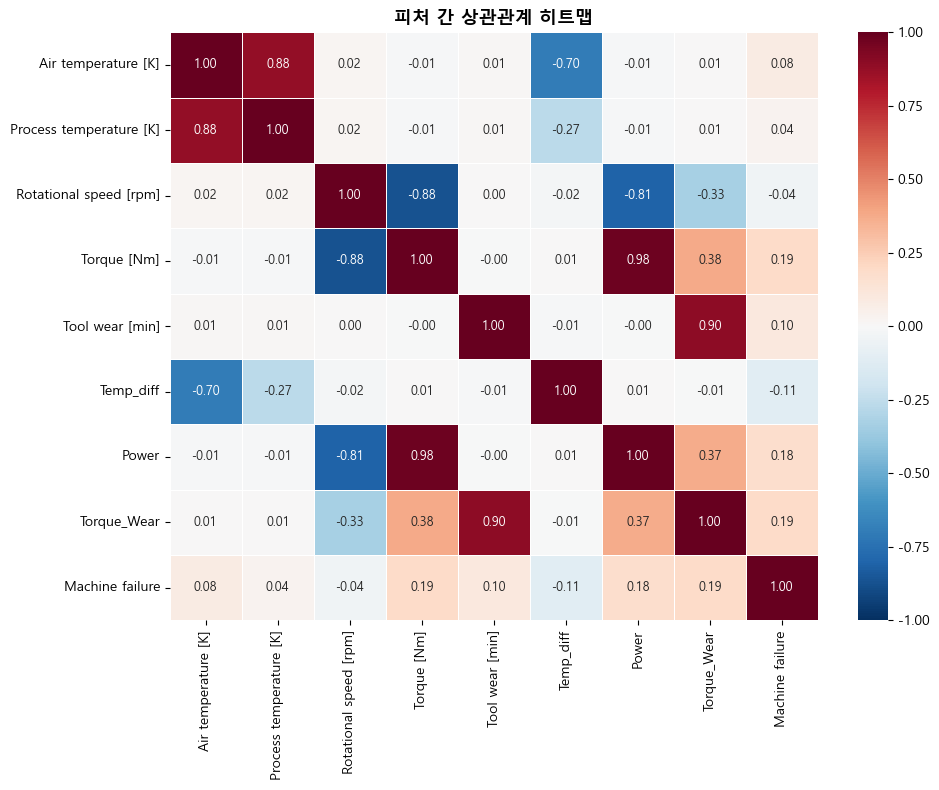

In [20]:
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r',
            vmin=-1, vmax=1, ax=ax,
            linewidths=0.5, annot_kws={'size': 9})
ax.set_title('피처 간 상관관계 히트맵', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

1. Air temp ↔ Process temp: 0.88 (강한 양의 상관)
공기 온도가 오르면 공정 온도도 같이 올라요. 근데 둘 다 Machine failure와의 상관은 0.08, 0.04로 낮아요. 즉 온도 자체보다 온도 차이(Temp_diff) 가 중요하다는 걸 히트맵이 보여주는 거예요.
2. Rotational speed ↔ Torque: -0.88 (강한 음의 상관)
물리적으로 당연한 결과예요. rpm이 높으면 토크가 낮고, rpm이 낮으면 토크가 높아요. 그래서 Power(= Torque × rpm)가 이 둘을 하나로 합친 의미 있는 파생변수가 되는 거예요.
3. Torque_Wear ↔ Tool wear: 0.90
Torque_Wear = Torque × Tool wear라서 Tool wear가 클수록 같이 커져요. 다중공선성 주의가 필요한 부분이에요. 나중에 모델링할 때 Tool wear랑 Torque_Wear를 둘 다 넣으면 중복 정보가 될 수 있어요.

In [23]:
!pip install statsmodels

   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   -------------- ------------------------- 3.4/9.5 MB 24.3 MB/s eta 0:00:01
   -------------------------------- ------- 7.9/9.5 MB 19.0 MB/s eta 0:00:01
   ---------------------------------------- 9.5/9.5 MB 21.4 MB/s  0:00:00

   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -----------------

In [24]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_cols = ['Air temperature [K]', 'Process temperature [K]',
            'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]',
            'Temp_diff', 'Power', 'Torque_Wear']

vif_df = pd.DataFrame()
vif_df['Feature'] = vif_cols
vif_df['VIF'] = [variance_inflation_factor(df[vif_cols].values, i)
                 for i in range(len(vif_cols))]

print(vif_df.sort_values('VIF', ascending=False).round(2))

                   Feature      VIF
0      Air temperature [K]      inf
1  Process temperature [K]      inf
5                Temp_diff      inf
6                    Power  1154.57
3              Torque [Nm]   879.60
2   Rotational speed [rpm]   428.56
7              Torque_Wear    66.30
4          Tool wear [min]    66.21


C:\Users\woain\miniconda3\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)
C:\Users\woain\miniconda3\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)
C:\Users\woain\miniconda3\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


In [25]:
# 모델링용 피처 확정
model_features = ['Type', 'Temp_diff', 'Power', 'Torque_Wear']

print("── 최종 피처로 VIF 재확인 ──")
# Type 인코딩 먼저
df['Type_encoded'] = df['Type'].map({'L': 0, 'M': 1, 'H': 2})

final_cols = ['Type_encoded', 'Temp_diff', 'Power', 'Torque_Wear']
vif_df2 = pd.DataFrame()
vif_df2['Feature'] = final_cols
vif_df2['VIF'] = [variance_inflation_factor(df[final_cols].values, i)
                  for i in range(len(final_cols))]
print(vif_df2.sort_values('VIF', ascending=False).round(2))

── 최종 피처로 VIF 재확인 ──
        Feature    VIF
2         Power  31.57
1     Temp_diff  27.31
3   Torque_Wear   3.84
0  Type_encoded   1.55


In [26]:
# Power와 Temp_diff 상관관계 확인
print(df[['Temp_diff', 'Power', 'Torque_Wear', 'Type_encoded']].corr().round(3))

              Temp_diff  Power  Torque_Wear  Type_encoded
Temp_diff         1.000  0.007       -0.005         0.012
Power             0.007  1.000        0.369        -0.005
Torque_Wear      -0.005  0.369        1.000        -0.010
Type_encoded      0.012 -0.005       -0.010         1.000


상관관계는 다 낮은데 VIF가 높음.
피처 스케일 차이 때문일 수도 있음 

In [27]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled = scaler.fit_transform(df[final_cols])
scaled_df = pd.DataFrame(scaled, columns=final_cols)

vif_df3 = pd.DataFrame()
vif_df3['Feature'] = final_cols
vif_df3['VIF'] = [variance_inflation_factor(scaled_df.values, i)
                  for i in range(len(final_cols))]
print("── 스케일링 후 VIF ──")
print(vif_df3.sort_values('VIF', ascending=False).round(2))

── 스케일링 후 VIF ──
        Feature   VIF
3   Torque_Wear  1.16
2         Power  1.16
1     Temp_diff  1.00
0  Type_encoded  1.00


In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor

# 데이터 로드 & 파생변수
df = pd.read_csv('ai4i2020.csv')
df.columns = df.columns.str.strip()

df['Temp_diff']    = df['Process temperature [K]'] - df['Air temperature [K]']
df['Power']        = df['Torque [Nm]'] * df['Rotational speed [rpm]'] * (2 * np.pi / 60)
df['Torque_Wear']  = df['Torque [Nm]'] * df['Tool wear [min]']
df['Type_encoded'] = df['Type'].map({'L': 0, 'M': 1, 'H': 2})

# 최종 피처 5개
final_cols = ['Type_encoded', 'Tool wear [min]', 'Temp_diff', 'Power', 'Torque_Wear']

# 스케일링 후 VIF
scaler = StandardScaler()
scaled_df = pd.DataFrame(scaler.fit_transform(df[final_cols]), columns=final_cols)

vif_df = pd.DataFrame()
vif_df['Feature'] = final_cols
vif_df['VIF'] = [variance_inflation_factor(scaled_df.values, i)
                 for i in range(len(final_cols))]

print(vif_df.sort_values('VIF', ascending=False).round(2))

           Feature    VIF
4      Torque_Wear  17.77
1  Tool wear [min]  15.35
3            Power   3.45
0     Type_encoded   1.00
2        Temp_diff   1.00
